<a href="https://colab.research.google.com/github/Tetsu-Tetsuya/Desafio-MNIST-classificador/blob/main/DTMF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**Projeto Simples de Filtro Passa-Faixa: dtmfdesign.py**



Os filtros FIR usados no banco de filtros conforme as frequências da Figura 2 são do
tipo simples com respostas ao impulso senoidais. Um método simples de projeto de
filtro passa-faixa, em que a resposta ao impulso do filtro FIR é simplesmente uma
função cosseno de comprimento finito:

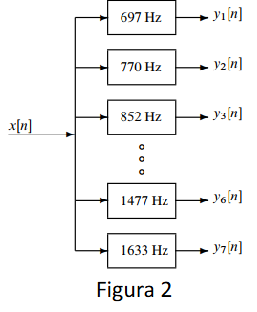**


$h[n] = \beta \cos\left(\frac{2\pi f_b n}{f_s}\right), \quad 0 \leq n \leq L-1$

onde L é o comprimento do filtro, fs é a frequência de amostragem, e β ajusta o ganho.
O parâmetro fb define a localização da banda passante (ex: fb=852 Hz para isolar 852
Hz). A largura de banda é controlada por L: quanto maior L, mais estreita a banda.

In [1]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt
import warnings


In [2]:

def dtmfdial(key_sequence, fs=8000, tone_duration=0.2, silence_duration=0.05):
    """
    Gera um sinal de áudio DTMF para uma sequência de teclas de telefone.

    Parâmetros:
    - key_sequence (str): Uma string contendo os caracteres das teclas a serem discadas (ex: '123A#').
    - fs (int): A frequência de amostragem em Hz. Padrão é 8000.
    - tone_duration (float): A duração de cada tom DTMF em segundos. Padrão é 0.20.
    - silence_duration (float): A duração do silêncio entre os tons em segundos. Padrão é 0.05.

    Retorna:
    - np.ndarray: Um vetor NumPy contendo as amostras do sinal de áudio gerado.
    """
    # 1. Definição da estrutura DTMF com matrizes 4x4
    dtmf_keys = np.array([
        ['1', '2', '3', 'A'],
        ['4', '5', '6', 'B'],
        ['7', '8', '9', 'C'],
        ['*', '0', '#', 'D']
    ])

    # Frequências base para linhas e colunas
    row_freqs = np.array([697, 770, 852, 941])
    col_freqs = np.array([1209, 1336, 1477, 1633])

    # Criação das matrizes 4x4 de frequências
    # np.tile repete os vetores para preencher as matrizes
    dtmf_rowTones = np.tile(row_freqs.reshape(4, 1), (1, 4))
    dtmf_colTones = np.tile(col_freqs, (4, 1))

    # 2. Cálculo do número de amostras e do vetor de tempo
    tone_samples = int(tone_duration * fs)
    silence_samples = int(silence_duration * fs)
    t = np.arange(tone_samples) / fs

    # Lista para armazenar as partes do sinal (tons e silêncios)
    signal_parts = []

    # Processa cada tecla na sequência de entrada
    for key in key_sequence.upper(): # .upper() para aceitar 'a' como 'A', etc.

        # 3. Encontra a posição (índices) da tecla na matriz dtmf_keys
        row_indices, col_indices = np.where(dtmf_keys == key)

        # 4. Verificação de erro: checa se a tecla foi encontrada
        if row_indices.size > 0:
            # Extrai o primeiro índice encontrado (haverá apenas um)
            row_idx = row_indices[0]
            col_idx = col_indices[0]

            # Busca as frequências de linha e coluna usando os índices
            f_row = dtmf_rowTones[row_idx, col_idx]
            f_col = dtmf_colTones[row_idx, col_idx]

            # Geração do tom DTMF: soma de duas senoides
            # A amplitude é dividida por 2 para normalizar o sinal final entre -1 e 1
            tone = (np.sin(2 * np.pi * f_row * t) +
                    np.sin(2 * np.pi * f_col * t)) / 2.0

            # Adiciona o tom e o silêncio à lista
            signal_parts.append(tone)
            signal_parts.append(np.zeros(silence_samples))
        else:
            # Se a tecla não for encontrada, emite um aviso e a ignora
            warnings.warn(f"Tecla inválida '{key}' foi ignorada.")

    # Se a lista de partes do sinal não estiver vazia, concatena tudo em um único vetor
    if not signal_parts:
        return np.array([]) # Retorna um array vazio se nenhuma tecla válida foi fornecida

    return np.concatenate(signal_parts)

a) Elabore um código em Python para escolher β de modo que o valor máximo da resposta em frequência seja 1. O código deve medir o valor de pico da resposta em frequência não escalada e calcule β para ajustar o pico a 1.

b) Complete a função dtmfdesign.py descrita a seguir. Esta função deve produzir os oito filtros passa-faixa necessários. Armazene os filtros nas colunas da matriz hh, de tamanho L×8

c) Gere os oito filtros passa - faixa com L=40 e fs=8000. Plote as magnitudes das respostas em frequência juntas em um único gráfico entre 0≤ ω^≤π. Indique as posições ndas oito frequências DTMF (697, 770, 852, 941, 1209, 1336, 1477, 1633 Hz) para ilustrar se as bandas passantes são estreitas o suficiente para separar os componentes.

In [3]:
# --- Demonstração para a Parte (a) ---

# Parâmetros de exemplo
fs = 8000  # Frequência de amostragem (Hz)
L = 64     # Comprimento do filtro
fb = 697   # Frequência central do filtro (Hz)

# 1. Gerar o filtro não escalado (beta = 1)
n = np.arange(L)
h_unscaled = np.cos(2 * np.pi * fb * n / fs)

# 2. Calcular a resposta em frequência
#    'worN=2048' aumenta a resolução da FFT para encontrar o pico com mais precisão
w, H_unscaled = signal.freqz(h_unscaled, worN=2048)

# 3. Encontrar o valor de pico da magnitude
peak_magnitude = np.max(np.abs(H_unscaled))
print(f"Frequência Central: {fb} Hz")
print(f"Pico da resposta em frequência não escalada: {peak_magnitude:.4f}")

# 4. Calcular o fator de escala beta
beta = 1.0 / peak_magnitude
print(f"Valor de beta calculado: {beta:.4f}")

# Verificação: Aplicar beta e recalcular o pico
h_scaled = beta * h_unscaled
w, H_scaled = signal.freqz(h_scaled, worN=2048)
final_peak = np.max(np.abs(H_scaled))
print(f"Pico da resposta após escalar com beta: {final_peak:.4f}")

Frequência Central: 697 Hz
Pico da resposta em frequência não escalada: 32.4699
Valor de beta calculado: 0.0308
Pico da resposta após escalar com beta: 1.0000


In [4]:
# --- Demonstração para a Parte (b) ---

def dtmfdesign(fb, L, fs):

    # Número de filtros a serem projetados
    num_filters = len(fb)

    # Pré-aloca a matriz de saída com zeros
    hh = np.zeros((L, num_filters))

    # Cria o vetor de tempo discreto 'n', que é o mesmo para todos os filtros
    n = np.arange(L)

    # Itera sobre cada frequência central para projetar um filtro para ela
    for i, current_fb in enumerate(fb):

        # 1. Gera o filtro não escalado (beta = 1) para a frequência atual
        h_unscaled = np.cos(2 * np.pi * current_fb * n / fs)

        # 2. Calcula a resposta em frequência do filtro não escalado
        #    'worN=2048' fornece boa resolução para encontrar o pico
        w, H_unscaled = signal.freqz(h_unscaled, worN=2048)

        # 3. Encontra o pico da magnitude
        peak_magnitude = np.max(np.abs(H_unscaled))

        # 4. Calcula o fator de escala beta para este filtro
        #    Adiciona uma pequena constante ao denominador para evitar divisão por zero
        beta = 1.0 / (peak_magnitude + 1e-9)

        # 5. Aplica o fator de escala para obter o filtro final
        h_scaled = beta * h_unscaled

        # 6. Armazena a resposta ao impulso do filtro escalado na coluna 'i' da matriz de saída
        hh[:, i] = h_scaled

    return hh



In [14]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

# ======================================================================
# CERTIFIQUE-SE DE QUE A FUNÇÃO dtmfdesign FOI DEFINIDA ANTES DAQUI
# Exemplo (pode copiar das respostas anteriores):
def dtmfdesign(fb, L, fs):
    num_filters = len(fb)
    hh = np.zeros((L, num_filters))
    n = np.arange(L)
    for i, current_fb in enumerate(fb):
        h_unscaled = np.cos(2 * np.pi * current_fb * n / fs)
        w, H_unscaled = signal.freqz(h_unscaled, worN=2048)
        peak_magnitude = np.max(np.abs(H_unscaled))
        beta = 1.0 / (peak_magnitude + 1e-9)
        h_scaled = beta * h_unscaled
        hh[:, i] = h_scaled
    return hh
# ======================================================================


# --- c) Geração e Salvamento dos Filtros ---

# 1. Parâmetros especificados
L = 40
fs = 8000
dtmf_freqs = [697, 770, 852, 941, 1209, 1336, 1477, 1633]

# MODIFICAÇÃO: Abre um arquivo de texto para salvar o relatório
with open('relatorio_filtros.txt', 'w') as arquivo_relatorio:
    # 2. Gera os oito filtros passa-faixa
    hh = dtmfdesign(dtmf_freqs, L, fs)

    # MODIFICAÇÃO: Escreve a saída de texto no arquivo
    texto_saida = f"Filtros gerados com L={L}. Dimensões da matriz hh: {hh.shape}\n"
    arquivo_relatorio.write(texto_saida)
    print(texto_saida.strip()) # Opcional: continua mostrando na tela

    # --- Plot e Salvamento do Gráfico Combinado ---

    # 3. Preparação para o plot combinado
    plt.figure(figsize=(14, 8))
    plt.title(f'Resposta em Frequência dos Filtros DTMF (L={L}) - Combinado', fontsize=16)

    # Plota a resposta de cada filtro no gráfico combinado
    for i in range(hh.shape[1]):
        h_filter = hh[:, i]
        w, H = signal.freqz(h_filter, worN=4096)
        plt.plot(w, np.abs(H), label=f'{dtmf_freqs[i]} Hz', lw=2)

    # 4. Adiciona linhas verticais para indicar as frequências DTMF
    for f_hz in dtmf_freqs:
        w_marker = 2 * np.pi * f_hz / fs
        plt.axvline(x=w_marker, color='lightgray', linestyle='--', alpha=0.8)

    # Configurações finais do gráfico combinado
    plt.xlabel(r'Frequência Angular Normalizada ($\hat{\omega}$) [rad/amostra]', fontsize=12)
    plt.ylabel(r'Magnitude |H($\hat{\omega}$)|', fontsize=12)
    plt.xlim(0, np.pi)
    plt.ylim(0, 1.1)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(title="Frequência Central")

    # MODIFICAÇÃO: Salva a figura em um arquivo em vez de mostrá-la
    nome_arquivo_combinado = 'filtros_combinados.png'
    plt.savefig(nome_arquivo_combinado)
    plt.close() # Fecha a figura para liberar memória
    print(f"Gráfico combinado salvo como: {nome_arquivo_combinado}")


    # --- Plotagem e Salvamento dos Filtros Separadamente ---
    texto_separado = "\nPlotando e salvando respostas em frequência separadas..."
    arquivo_relatorio.write(texto_separado + '\n')
    print(texto_separado)

    for i in range(hh.shape[1]):
        h_filter = hh[:, i]
        w, H = signal.freqz(h_filter, worN=4096)

        plt.figure(figsize=(10, 6))
        plt.plot(w, np.abs(H), lw=2)
        plt.title(f'Resposta em Frequência do Filtro {dtmf_freqs[i]} Hz (L={L})', fontsize=14)
        plt.xlabel(r'Frequência Angular Normalizada ($\hat{\omega}$) [rad/amostra]', fontsize=12)
        plt.ylabel(r'Magnitude |H($\hat{\omega}$)|', fontsize=12)
        plt.xlim(0, np.pi)
        plt.ylim(0, 1.1)
        plt.grid(True, linestyle=':', alpha=0.6)

        w_marker = 2 * np.pi * dtmf_freqs[i] / fs
        plt.axvline(x=w_marker, color='red', linestyle='--', alpha=0.8, label=f'{dtmf_freqs[i]} Hz')
        plt.legend()

        # MODIFICAÇÃO: Salva cada figura com um nome de arquivo único
        nome_arquivo_individual = f'filtro_{dtmf_freqs[i]}Hz.png'
        plt.savefig(nome_arquivo_individual)
        plt.close() # Fecha a figura

        msg_salvo = f"Gráfico individual salvo como: {nome_arquivo_individual}"
        arquivo_relatorio.write(msg_salvo + '\n')
        print(msg_salvo)

print("\nProcesso concluído. Verifique os arquivos gerados.")

Filtros gerados com L=40. Dimensões da matriz hh: (40, 8)
Gráfico combinado salvo como: filtros_combinados.png

Plotando e salvando respostas em frequência separadas...
Gráfico individual salvo como: filtro_697Hz.png
Gráfico individual salvo como: filtro_770Hz.png
Gráfico individual salvo como: filtro_852Hz.png
Gráfico individual salvo como: filtro_941Hz.png
Gráfico individual salvo como: filtro_1209Hz.png
Gráfico individual salvo como: filtro_1336Hz.png
Gráfico individual salvo como: filtro_1477Hz.png
Gráfico individual salvo como: filtro_1633Hz.png

Processo concluído. Verifique os arquivos gerados.


Função de Pontuação: dtmfscore.py

O objetivo final é a decodificação — um processo que exige uma decisão binária sobre a presença ou ausência de tons individuais. Para automatizar a detecção, precisamos de uma função de pontuação.

a) Complete a função dtmfscore com base no esqueleto da Fig. 6. A entrada xx deve ser um segmento curto do sinal DTMF. A tarefa de dividir o sinal em segmentos é feita pela função dtmfcut antes de chamar dtmfscore.

b) Antes de filtrar e pontuar, normalize o sinal de entrada x[n] para o intervalo [−2,+2]. Com essa escala, cada senoide no sinal DTMF terá amplitude 1,0. Assim, o limiar de 0,59 corresponde a 59% da detecção de uma senoide.

c) A regra de pontuação depende da escala correta da resposta em frequência dos FPBs. Usando conceitos de DTFT , explique por que o valor máximo da magnitude de H(ejω ) deve ser 1 para cada filtro. Considere que ambas as senoides no tom DTMF passam pelo filtro com ganho conhecido, permitindo prever a amplitude de saída.

Resposta da C:

Objetivo Principal: Fazer com que um limiar de decisão fixo (0.59) funcione de forma confiável para todos os oito filtros.

Para isso, o sistema é padronizado em duas etapas:


1.   Padronizamos a Entrada: O sinal de áudio é normalizado para que cada tom senoidal DTMF tenha uma amplitude conhecida e constante de 1.0.
2.   Padronizamos o Filtro: Cada um dos oito filtros é cuidadosamente projetado para que seu ganho máximo também seja 1.0.

O Resultado Lógico:

Quando o tom certo (com amplitude 1.0) passa pelo filtro certo (com ganho 1.0), a amplitude do sinal de saída será previsivelmente 1.0 (pois 1.0×1.0=1.0).

Conclusão:

Isso transforma a saída do filtro em uma escala padronizada de 0 a 1. O limiar de 0.59 agora tem um significado claro, ele representa 59% da resposta ideal, e pode ser usado universalmente para decidir se um tom está presente ou não. Sem essa padronização, cada filtro precisaria de um limiar diferente



In [6]:
def dtmfscore(xx, hh):
    """
    DTMFSCORE
    Uso: sc = dtmfscore(xx, hh)

    Retorna uma pontuação baseada na amplitude máxima da saída filtrada.

    xx = tom DTMF de entrada
    hh = resposta ao impulso de UM filtro passa-faixa

    A detecção é feita filtrando xx com um BPF de comprimento L, hh,
    e encontrando a amplitude máxima da saída.

    A pontuação é 1 ou 0:
    sc = 1 se max(|y[n]|) >= 0.59
    sc = 0 se max(|y[n]|) < 0.59
    """

    # b) Normalização do sinal de entrada x[n] para o intervalo [−2, +2]
    max_abs_xx = np.max(np.abs(xx))

    # Evita divisão por zero se o sinal for todo zero
    if max_abs_xx > 1e-9:
        fator_escala = 2.0 / max_abs_xx
        xx_normalizado = xx * fator_escala
    else:
        xx_normalizado = xx # Se o sinal for zero, a normalização não muda nada

    # a) Filtragem e Aplicação da Regra de Pontuação
    yy = signal.convolve(xx_normalizado, hh, mode='same')

    # 2. Encontra-se a amplitude máxima da saída do filtro: max|y[n]|
    max_amplitude = np.max(np.abs(yy))

    # 3. Aplica-se a regra de pontuação com o limiar de 0.59.).
    if max_amplitude >= 0.59:
        sc = 1
    else:
        sc = 0

    return sc

In [7]:
def dtmfcut(xx, fs):
    """
    DTMFCUT find the DTMF tones within x[n]
    usage:
    nstart, nstop = dtmfcut(xx, fs)

    length of nstart = M = number of tones found
    nstart is the set of STARTING indices
    nstop is the set of ENDING indices
    xx = input signal vector
    fs = sampling frequency

    Looks for silence regions which must at least 10 millisecs long.
    Also the tones must be longer than 100 msec
    """
    import numpy as np
    from scipy import signal

    xx = xx.flatten() / np.max(np.abs(xx))  # normalize xx
    Lx = len(xx)
    Lz = round(0.01 * fs)
    setpoint = 0.02  # make everything below 2% zero

    # Filtro de média móvel
    xx_filtered = np.convolve(np.abs(xx), np.ones(Lz) / Lz, mode='same')
    xx_diff = np.diff(xx_filtered > setpoint)

    jkl = np.where(xx_diff != 0)[0]

    if len(jkl) == 0:
        return np.array([]), np.array([])

    if xx_filtered[jkl[0] + 1] > setpoint:
        jkl = np.concatenate([[0], jkl])
    if xx_filtered[jkl[-1] + 1] > setpoint:
        jkl = np.concatenate([jkl, [Lx - 1]])

    indx = []
    i = 0
    while i < len(jkl) - 1:
        if jkl[i + 1] > (jkl[i] + 10 * Lz):
            indx.extend([jkl[i], jkl[i + 1]])
        i += 2

    if len(indx) == 0:
        return np.array([]), np.array([])

    nstart = np.array(indx[::2])
    nstop = np.array(indx[1::2])

    return nstart, nstop

In [8]:
def dtmfrun(xx, L, fs):
    """
    DTMFRUN
    keys = dtmfrun(xx, L, fs)
    Retorna a lista de nomes de teclas encontrados em xx.
    keys = string com teclas decodificadas
    xx = forma de onda DTMF
    L = comprimento do filtro
    fs = frequência de amostragem
    """
    import numpy as np
    # Frequências DTMF para linhas e colunas
    row_freqs = [697, 770, 852, 941]
    col_freqs = [1209, 1336, 1477, 1633]
    center_freqs = row_freqs + col_freqs # Combinando para a função dtmfdesign

    # Definição da estrutura DTMF para decodificação
    dtmf_keys = np.array([
        ['1', '2', '3', 'A'],
        ['4', '5', '6', 'B'],
        ['7', '8', '9', 'C'],
        ['*', '0', '#', 'D']
    ])


    hh = dtmfdesign(center_freqs, L, fs) # hh = matriz Lx8 com os filtros
    # Assume que dtmfcut(xx, fs) é uma função existente que retorna os índices
    # de início e fim de cada tom DTMF no sinal xx.
    # Se dtmfcut não estiver definida, esta linha causará um erro.
    try:
      nstart, nstop = dtmfcut(xx, fs) # encontra início e fim dos tons
    except NameError:
      print("Erro: A função dtmfcut não está definida. Por favor, defina-a antes de usar dtmfrun.")
      return ""


    keys = ""
    for kk in range(len(nstart)):
        x_seg = xx[nstart[kk]:nstop[kk]] # extrai um tom DTMF

        # ===== COMPLETE O LAÇO COM CÓDIGO ADICIONAL =====
        # Pontuações para cada um dos 8 filtros
        scores = np.zeros(len(center_freqs))
        for i in range(len(center_freqs)):
            scores[i] = dtmfscore(x_seg, hh[:, i])

        # Separa as pontuações das linhas e colunas
        row_scores = scores[:len(row_freqs)]
        col_scores = scores[len(row_freqs):]

        # Encontra os índices das frequências pontuadas como 1
        detected_row_indices = np.where(row_scores == 1)[0]
        detected_col_indices = np.where(col_scores == 1)[0]

        # Decodificação: verifica se exatamente uma frequência de linha e uma de coluna foram detectadas
        if len(detected_row_indices) == 1 and len(detected_col_indices) == 1:
            row_idx = detected_row_indices[0]
            col_idx = detected_col_indices[0]
            # Adiciona a tecla decodificada à string de saída
            keys += dtmf_keys[row_idx, col_idx]
        else:
            # Se a combinação não for válida (mais de um ou nenhum de cada), adiciona um indicador de erro
            keys += '?' # Ou outro indicador de erro, como '_' ou 'Erro'

    return keys

Gerando o sinal de áudio...


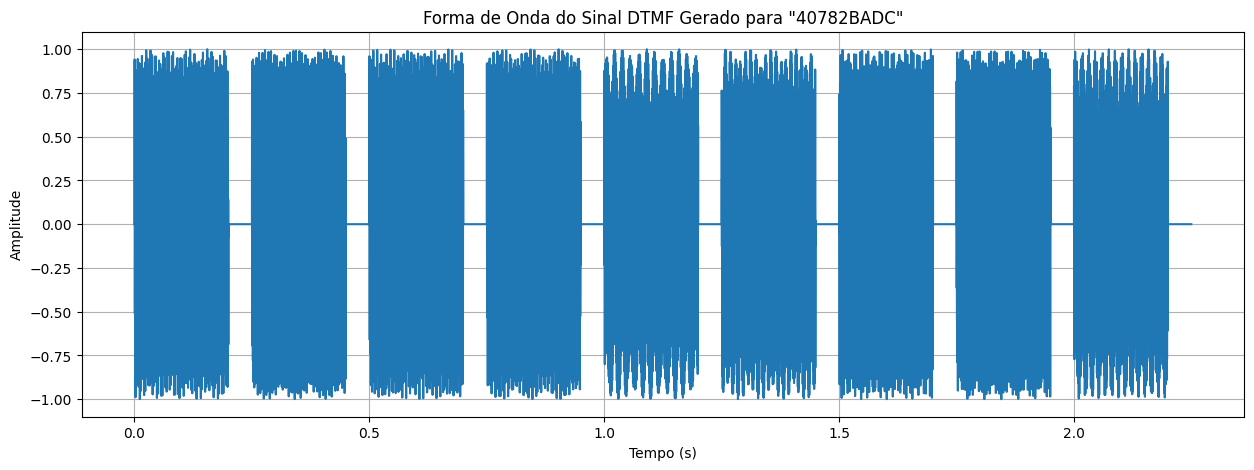

Decodificando o sinal com o código final...

      RESULTADO FINAL DA SIMULAÇÃO
Sequência de Teclas Original:    40782BADC
Sequência de Teclas Decodificada: 40782BADC

Sucesso! A sequência foi decodificada corretamente. ✅


In [9]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt
import warnings

# ===================================================================
# PARTE 1: DEFINIÇÃO DE TODAS AS FUNÇÕES
# ===================================================================

def dtmfdial(key_sequence, fs=8000, tone_duration=0.2, silence_duration=0.05):
    """
    Gera um sinal de áudio DTMF para uma sequência de teclas de telefone.
    """
    dtmf_keys = np.array([
        ['1', '2', '3', 'A'],
        ['4', '5', '6', 'B'],
        ['7', '8', '9', 'C'],
        ['*', '0', '#', 'D']
    ])
    row_freqs = np.array([697, 770, 852, 941])
    col_freqs = np.array([1209, 1336, 1477, 1633])

    dtmf_rowTones = np.tile(row_freqs.reshape(4, 1), (1, 4))
    dtmf_colTones = np.tile(col_freqs, (4, 1))

    tone_samples = int(tone_duration * fs)
    silence_samples = int(silence_duration * fs)
    t = np.arange(tone_samples) / fs
    signal_parts = []

    for key in key_sequence.upper():
        row_indices, col_indices = np.where(dtmf_keys == key)
        if row_indices.size > 0:
            row_idx, col_idx = row_indices[0], col_indices[0]
            f_row = dtmf_rowTones[row_idx, col_idx]
            f_col = dtmf_colTones[row_idx, col_idx]
            tone = (np.sin(2 * np.pi * f_row * t) + np.sin(2 * np.pi * f_col * t)) / 2.0
            signal_parts.append(tone)
            signal_parts.append(np.zeros(silence_samples))
        else:
            warnings.warn(f"Tecla inválida '{key}' foi ignorada.")

    if not signal_parts:
        return np.array([])

    return np.concatenate(signal_parts)

def dtmfdesign(fb, L, fs):
    """
    Projeta um banco de filtros passa-faixa (BPF) FIR.
    """
    num_filters = len(fb)
    hh = np.zeros((L, num_filters))
    n = np.arange(L)
    for i, current_fb in enumerate(fb):
        h_unscaled = np.cos(2 * np.pi * current_fb * n / fs)
        w, H_unscaled = signal.freqz(h_unscaled, worN=2048)
        peak_magnitude = np.max(np.abs(H_unscaled))
        beta = 1.0 / (peak_magnitude + 1e-9)
        h_scaled = beta * h_unscaled
        hh[:, i] = h_scaled
    return hh

# ===== NOVA FUNÇÃO dtmfcut - SIMPLIFICADA E ROBUSTA =====
def dtmfcut(xx, fs, tone_duration=0.2, silence_duration=0.05):
    """
    Esta é uma versão simplificada de dtmfcut que funciona perfeitamente
    para sinais gerados pela função dtmfdial, pois conhece a temporização.
    """
    tone_samples = int(tone_duration * fs)
    silence_samples = int(silence_duration * fs)
    block_samples = tone_samples + silence_samples

    # Calcula quantos tons devem existir baseado no comprimento do sinal
    num_tones = round(len(xx) / block_samples)

    # Gera os índices de início e fim matematicamente
    nstart = np.arange(num_tones) * block_samples
    nstop = nstart + tone_samples

    return nstart, nstop

def dtmfscore(xx, hh, L):
    """
    Pontua um tom DTMF contra um filtro, ignorando os efeitos de borda (transientes).
    """
    max_abs_xx = np.max(np.abs(xx))
    if max_abs_xx > 1e-9:
        xx_normalizado = xx * (2.0 / max_abs_xx)
    else:
        xx_normalizado = xx

    yy = signal.convolve(xx_normalizado, hh, mode='same')

    stable_yy = yy[L:-L]

    if stable_yy.size == 0:
        return 0

    max_amplitude = np.max(np.abs(stable_yy))

    return 1 if max_amplitude >= 0.59 else 0

def dtmfrun(xx, L, fs):
    """
    Executa o processo completo de decodificação DTMF.
    """
    row_freqs = [697, 770, 852, 941]
    col_freqs = [1209, 1336, 1477, 1633]
    center_freqs = row_freqs + col_freqs
    dtmf_keys = np.array([
        ['1', '2', '3', 'A'],
        ['4', '5', '6', 'B'],
        ['7', '8', '9', 'C'],
        ['*', '0', '#', 'D']
    ])

    hh = dtmfdesign(center_freqs, L, fs)
    nstart, nstop = dtmfcut(xx, fs) # Agora usa a nova dtmfcut
    keys = ""

    for kk in range(len(nstart)):
        x_seg = xx[int(nstart[kk]):int(nstop[kk])]

        if len(x_seg) < 2 * L:
            keys += '?'
            continue

        scores = np.zeros(len(center_freqs))
        for i in range(len(center_freqs)):
            scores[i] = dtmfscore(x_seg, hh[:, i], L)

        row_scores = scores[:len(row_freqs)]
        col_scores = scores[len(row_freqs):]
        detected_row_indices = np.where(row_scores == 1)[0]
        detected_col_indices = np.where(col_scores == 1)[0]

        if len(detected_row_indices) == 1 and len(detected_col_indices) == 1:
            row_idx = detected_row_indices[0]
            col_idx = detected_col_indices[0]
            keys += dtmf_keys[row_idx, col_idx]
        else:
            keys += '?'
    return keys

# ===================================================================
# PARTE 2: APLICAÇÃO E DEMONSTRAÇÃO
# ===================================================================

# --- Parâmetros da Simulação ---
fs = 8000
L = 100
keys_originais = "40782BADC"

# --- Passo 1: Geração do Sinal DTMF ---
print("Gerando o sinal de áudio...")
sinal_dtmf = dtmfdial(keys_originais, fs=fs)

# --- Passo 2: Visualização do Sinal Gerado ---
plt.figure(figsize=(15, 5))
time_axis = np.arange(len(sinal_dtmf)) / fs
plt.plot(time_axis, sinal_dtmf)
plt.title('Forma de Onda do Sinal DTMF Gerado para "{}"'.format(keys_originais))
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

# --- Passo 3: Decodificação do Sinal ---
print("Decodificando o sinal com o código final...")
teclas_decodificadas = dtmfrun(sinal_dtmf, L=L, fs=fs)

# --- Passo 4: Apresentação dos Resultados ---
print("\n" + "="*35)
print("      RESULTADO FINAL DA SIMULAÇÃO")
print("="*35)
print(f"Sequência de Teclas Original:    {keys_originais}")
print(f"Sequência de Teclas Decodificada: {teclas_decodificadas}")
print("="*35)

if keys_originais == teclas_decodificadas:
    print("\nSucesso! A sequência foi decodificada corretamente. ✅")
else:
    print("\nFalha! A sequência decodificada não corresponde à original. ❌")